## Saddle-Node Bifurcation

In [1]:
pip install -U chaospy numpoly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy, chaospy, numpoly
print(numpy.__version__, chaospy.__version__, numpoly.__version__)

2.2.4 4.3.18 1.3.6


100%|██████████| 4/4 [00:24<00:00,  6.10s/it]


Number of distinct solutions: 4


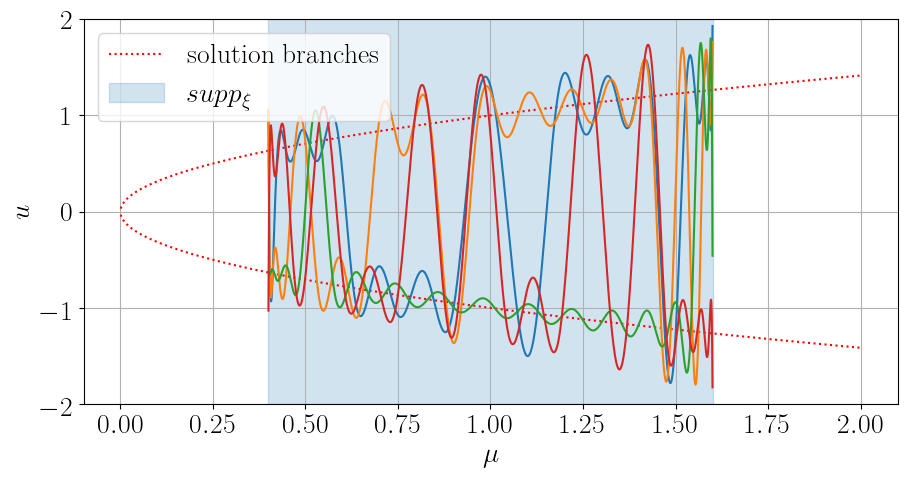

In [4]:
import chaospy as cp
import numpy as np
from scipy.optimize import root
from scipy.stats import gaussian_kde, wasserstein_distance
from scipy.signal import find_peaks
import scipy.special as scp
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.patches as patches

#np.random.seed(241)

# matplotlib.pyplot options
plt.rcParams['text.latex.preamble']=r"\usepackage{lmodern}"
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 20
plt.rcParams['font.family'] = 'lmodern'

#-------------------------------------------------------------------------------------------------------------------------
#Code solving u(u^2-mu)=0 (*)

#mu --> parameter --(KL)--> mu = \mathbb{E}[\mu] + \sigma\xi
#\sigma --> standard deviation of \mu
#\xi --(centered and rescaled \mu)--> \mu centered, i.e. \mathbb{E}[\xi]=0, and rescaled, i.e. \mathbb{E}[\xi^2]=1

#u --> solution --(PC)--> u=\sum_{i=1}^{N_{PC}} c_i \phi_i(\xi) 

#We will refer to (*) as F(c)=0
#-------------------------------------------------------------------------------------------------------------------------

class Saddle_Node():
    def __init__(self, mu, base_mu, distribution = 'Uniform', n_samples=1000):
        '''
        mu --> {chaospy.Distribution}
        base_mu --> {chaospy.Distribution}
        n_samples --> {int}
        '''
        self.mu = mu
        self.base_mu = base_mu
        self.n_samples = n_samples
        self.distribution = distribution

        # collect samples from mu and base_mu
        self.mu_base_samples = np.sort(self.base_mu.sample(n_samples))
        self.mu_samples = self.mu_base_samples*cp.Std(self.mu) + cp.E(self.mu)

    def f(self, c):
        '''
        compute F(c)
        '''
        c = c.reshape((self.n_pc,1))
        assert c.shape==(self.n_pc,1), f"c must be of shape {(self.n_pc,1)}, instead it is of shape {c.shape}"
        u = c.T @ self.phi(self.mu_base_samples)
        I = (u**2-self.mu_samples)
        II = (I @ self.phi(self.mu_base_samples).T)/self.n_samples
        return II.flatten()

    def run(self, degree_pc, n_init):
        '''
        solve F(c)=0 for n_init different initializations of the nonlinear solver

        degree_pc --> {int}
        n_init --> {int}
        '''
        # assemble matrices
        self.phi, self.phi_norm = cp.generate_expansion(degree_pc, self.base_mu, retall=True)
        self.n_pc = len(self.phi_norm)
        self.M = {0:(self.phi(self.mu_base_samples) @ self.phi(self.mu_base_samples).T)/self.n_samples,
                  1:self.phi(self.mu_base_samples),
                  2: (self.mu_samples @ self.phi(self.mu_base_samples).T)/self.n_samples}
        
        # Returns the classical Legendre polynomials, and not the monic ones
        
        if self.distribution == 'Uniform':
            coeffs = np.array([(2**i * scp.factorial(i)**2*(np.sqrt(3)**i))/(scp.factorial(2 * i)) for i in range(self.n_pc)])
            self.phi = self.phi / coeffs

        #print(self.phi)

        self.solution = np.zeros((n_init,self.n_pc))
        self.coeff_init = []
        for i in tqdm(range(n_init)):
            # generate random initializations
            self.coeff_init.append(0.5*np.random.randn(self.n_pc, 1))

            # solve F(c)=0
            sol = root(self.f, self.coeff_init[-1], method='hybr', tol=1e-15)
            u = (sol.x).T @ self.phi(self.mu_base_samples)
            I = (u**2-self.mu_samples)
            II = (I @ self.phi(self.mu_base_samples).T)/self.n_samples
            #print(f"Vector of residuals: {II}")
            # save the solution
            self.solution[i] = sol.x
            #print(f"Solution: {sol.x}")
        self.solution_samples = (self.solution @ self.phi(self.mu_base_samples))

    def unique_solutions(self):
        unique = [list(self.solution[0])]
        for i in range(len(self.solution)):
            for j in range(0,i):
                if abs(self.solution[i][0]-self.solution[j][0])<=10**(-6):
                    break
                if j == i-1:
                    unique.append(list(self.solution[i]))
        return unique
                    

    def plot_poly(self, x_mu, idx_poly, init_poly=False,transparent=True,index=1):
        fig, ax = plt.subplots(1,1, figsize=(10.5,5))
        # plot the bifurcation diagram
        idx_0 = np.argmax(x_mu>=0)
        ax.plot(x_mu[idx_0:], np.sqrt(x_mu[idx_0:]),color="red",linestyle=":",label="solution branches")
        ax.plot(x_mu[idx_0:], -np.sqrt(x_mu[idx_0:]),color="red",linestyle=":")
        # plot the support of \xi
        tmp = max([max(self.mu_samples)-cp.E(self.mu), cp.E(self.mu)- min(self.mu_samples)])
        rect = patches.Rectangle((cp.E(self.mu)-tmp, -2), 2*tmp, 4, color="#1f77b4", alpha=0.2, label=r"$supp_{\xi}$")
        ax.add_patch(rect)
        # plot polynomials
        for s in idx_poly:
            ax.plot(self.mu_samples, self.solution[s] @ self.phi(self.mu_base_samples))
        # put labels and save 
        ax.set_xlabel(rf"$\mu$")
        ax.set_ylabel(rf"$u$")
        ax.grid(True)
        ax.set_ylim([-2,2])
        ax.legend(loc="upper left", ncol=1)
        fig.savefig(f"Plots/Saddle_Node_{index}poly_{[len(idx_poly)]}.png", bbox_inches="tight", transparent=transparent)
        # plt.close(fig)

for i in range(0,1):
    saddle_node = Saddle_Node( mu=cp.Uniform(0.4,1.6), base_mu=cp.Uniform(-np.sqrt(3),np.sqrt(3)), distribution = 'Uniform', n_samples=10000)
    
    #saddle_node = Saddle_Node( mu=cp.Normal(1,0.05), base_mu=cp.Normal(0,1), type = distribution = 'Uniform', n_samples=1000)
    
    num=4

    saddle_node.run(degree_pc=30, 
                    n_init=num)
    
    unique_solutions = saddle_node.unique_solutions()
    with open("output.txt", "w") as file:
        file.write(f"{unique_solutions}")
    print(f"Number of distinct solutions: {len(unique_solutions)}")

    saddle_node.plot_poly(x_mu = np.linspace(-1,2,2000), 
                        idx_poly=[i for i in range(0,num)], 
                        init_poly=False, 
                        transparent=False,index=i)